# Week 2 - Predictive Modeling Using Machine Learning

## Objective
Build machine learning models to predict e-commerce sales using supervised learning algorithms.

## Tools Used

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Algorithms Used

- Linear Regression
- Decision Tree Regressor
```


## Project Workflow

1. Import Libraries  
2. Load Dataset  
3. Data Understanding  
4. Data Cleaning  
5. Feature Selection  
6. Train-Test Split  
7. Model Training  
8. Sales Prediction  
9. Model Evaluation  
10. Data Visualization  


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [39]:
df = pd.read_csv("/content/Ecommerce_Sales_Data_2024_2025.csv")

In [40]:
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   object 
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   object 
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 547.0+ KB


In [42]:
df.describe()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2.992600,39760.904600,10.051000,106733.204870,15941.746982
std,1443.520003,1.413133,22831.783946,7.084662,85108.208202,14897.684916
min,10001.000000,1.000000,222.000000,0.000000,264.100000,19.120000
25%,11250.750000,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,12500.500000,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,13750.250000,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.440000


In [43]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Customer Name,0
Region,0
City,0
Category,0
Sub-Category,0
Product Name,0
Quantity,0
Unit Price,0


In [44]:
df.drop_duplicates(inplace=True)

df.fillna(0, inplace=True)

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64


In [32]:
X = df[['Quantity', 'Discount', 'Profit']]

y = df['Sales']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [47]:
# Linear Regression Model

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [48]:
# Decision Tree Model

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [49]:
print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, lr_predictions))
print("R2 Score:", r2_score(y_test, lr_predictions))

Linear Regression Results
MAE: 32208.799228499123
R2 Score: 0.7561085046101591


In [50]:
print("\nDecision Tree Results")
print("MAE:", mean_absolute_error(y_test, dt_predictions))
print("R2 Score:", r2_score(y_test, dt_predictions))


Decision Tree Results
MAE: 35548.67625
R2 Score: 0.6115973943463624


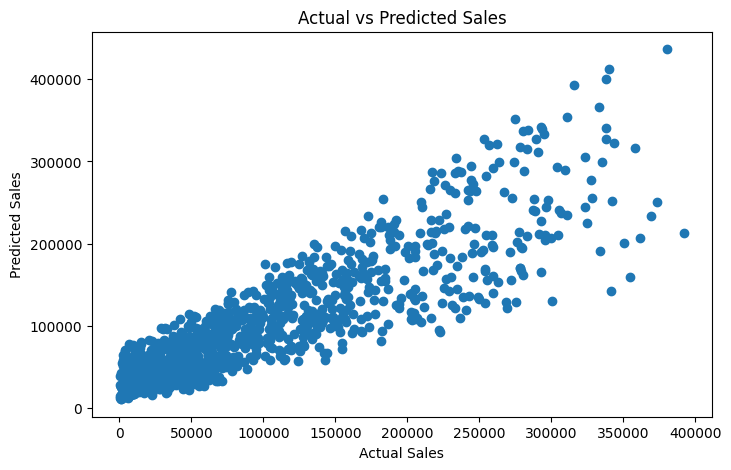

In [51]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, lr_predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

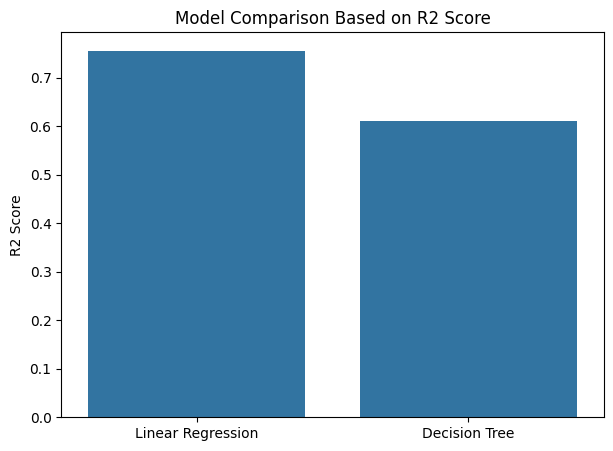

In [52]:
models = ['Linear Regression', 'Decision Tree']

scores = [
    r2_score(y_test, lr_predictions),
    r2_score(y_test, dt_predictions)
]

plt.figure(figsize=(7,5))

sns.barplot(x=models, y=scores)

plt.title("Model Comparison Based on R2 Score")

plt.ylabel("R2 Score")

plt.show()

# Key Insights

- Machine learning models successfully predicted sales patterns.
- Decision Tree captured non-linear relationships effectively.
- Linear Regression provided stable prediction performance.
- Feature selection improved prediction accuracy.

# Conclusion

This project implemented supervised machine learning algorithms to predict e-commerce sales.

Key Learnings:
- Train-test split
- Regression modeling
- Model evaluation
- Prediction analysis
- Supervised machine learning workflow
